## 3.3 实践: 基于Softmax回归完成鸢尾花分类任务

### 3.3.1 数据处理
#### 3.3.1.2 数据清洗

In [1]:
from sklearn.datasets import load_iris
import pandas
import numpy as np

iris_features = np.array(load_iris().data, dtype=np.float32)
iris_labels = np.array(load_iris().target, dtype=np.int32)
print(pandas.isna(iris_features).sum())
print(pandas.isna(iris_labels).sum())

0
0


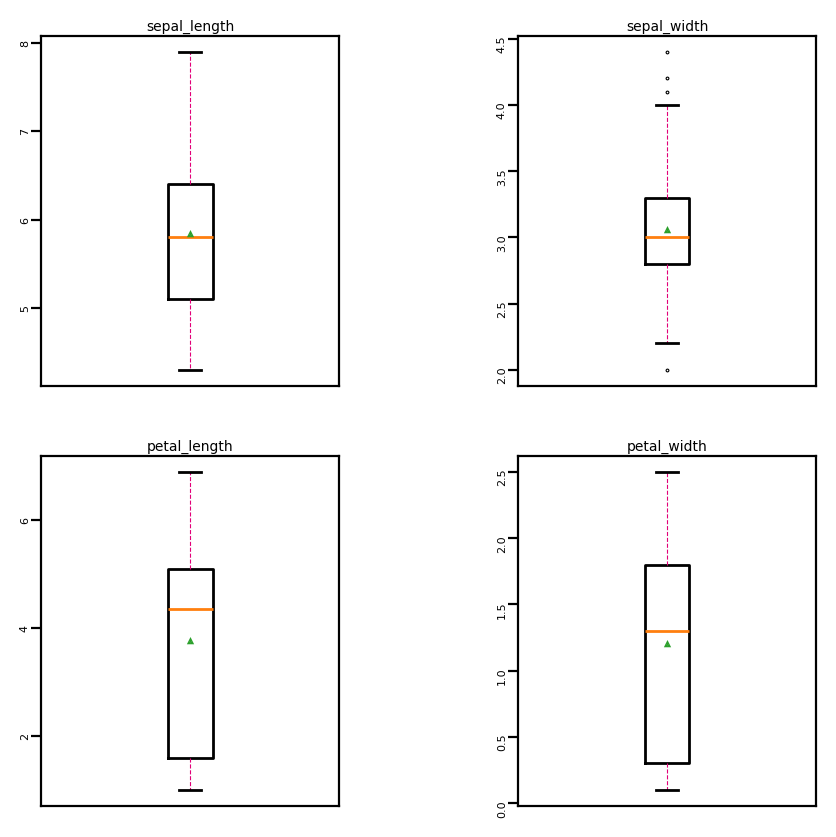

In [2]:
import matplotlib.pyplot as plt  # 可视化工具

# 箱线图查看异常值分布
def boxplot(features):
    feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

    # 连续画几个图片
    plt.figure(figsize=(5, 5), dpi=200)
    # 子图调整
    plt.subplots_adjust(wspace=0.6)
    # 每个特征画一个箱线图
    for i in range(4):
        plt.subplot(2, 2, i+1)
        # 画箱线图
        plt.boxplot(features[:, i],
                   showmeans=True,
                   whiskerprops={"color":"#E20079", "linewidth":0.4, "linestyle":"--"},
                   flierprops={"markersize":0.4},
                   meanprops={"markersize":1})
        # 图名
        plt.title(feature_names[i], fontdict={"size":5}, pad=2)
        # y方向刻度
        plt.yticks(fontsize=4, rotation=90)
        plt.tick_params(pad=0.5)
        # x方向刻度
        plt.xticks([])
    plt.savefig("ml-vis.pdf")
    plt.show()

boxplot(iris_features)

#### 3.3.1.3 数据读取

In [3]:
import copy
import paddle

# 加载数据集
def load_data(shuffle=True):
    """
    加载鸢尾花数据
    输入:
        - shuffle: 是否打乱数据，数据类型为bool
    输出:
        - X: 特征数据, shape=[150, 4]
        - y: 标签数据, shape=[150]
    """
    # 加载原始数据
    X = np.array(load_iris().data, dtype=np.float32)
    y = np.array(load_iris().target, dtype=np.int32)

    X = paddle.to_tensor(X)
    y = paddle.to_tensor(y)

    # 数据归一化
    X_min = paddle.min(X, axis=0)
    X_max = paddle.max(X, axis=0)
    X = (X-X_min) / (X_max-X_min)

    # 如果shuffle为 True, 随机打乱数据
    if shuffle:
        idx = paddle.randperm(X.shape[0])
        X = X[idx]
        y = y[idx]
    return X, y


# 固定随机种子
paddle.seed(102)

num_train = 120
num_dev = 15
num_test = 15

X, y = load_data(shuffle=True)
print("X shape: ", X.shape, "y shape: ", y.shape)
X_train, y_train = X[:num_train], y[:num_train]
X_dev, y_dev = X[num_train: num_train+num_dev], y[num_train: num_train + num_dev]
X_test, y_test = X[num_train + num_dev:], y[num_train + num_dev:]

X shape:  [150, 4] y shape:  [150]


In [4]:
# 打印X_train 和 y_train 的维度
print("X_train shape: ", X_train.shape, "y_train shape: ", y_train.shape)

X_train shape:  [120, 4] y_train shape:  [120]


In [5]:
# 打印前五个数据的标签
print(y_train[:5])

Tensor(shape=[5], dtype=int32, place=Place(cpu), stop_gradient=True,
       [2, 1, 2, 0, 2])


### 3.3.2 模型构建

In [6]:
from nndl_study import op

# 输入维度
input_dim = 4
# 类别数
output_dim = 3
# 实例化模型
model = op.model_SR(input_dim, output_dim=output_dim)

### 3.3.3 模型训练

In [7]:
from nndl_study import op, metric, optimizer, RunnerV2

# 学习率
lr = 0.2

# 梯度下降法
optimizer = optimizer.SimpleBatchGD(init_lr=lr, model=model)
# 交叉熵损失
loss_fn = op.MultiCrossEntropyLoss()
# 准确率
metric = metric.accuracy

# 实例化RunnerV2
runner = RunnerV2(model, optimizer, metric, loss_fn)

# 启动训练
runner.train([X_train, y_train], [X_dev, y_dev], num_epochs=200, log_epochs=10, 
             save_path="best_model.pdparams")

best accuracy performence has been updated:  0.00000 -->  0.33333
[Train] epoch: 0, loss: 1.09861159324646, score: 0.32499998807907104
[Dev] epoch: 0, loss: 1.0831197500228882, score: 0.3333333432674408
best accuracy performence has been updated:  0.33333 -->  0.46667
best accuracy performence has been updated:  0.46667 -->  0.53333
best accuracy performence has been updated:  0.53333 -->  0.66667
best accuracy performence has been updated:  0.66667 -->  0.73333
[Train] epoch: 10, loss: 0.9796913266181946, score: 0.6583333611488342
[Dev] epoch: 10, loss: 0.9740908741950989, score: 0.7333333492279053
[Train] epoch: 20, loss: 0.9011325836181641, score: 0.6833333373069763
[Dev] epoch: 20, loss: 0.8942919969558716, score: 0.7333333492279053
[Train] epoch: 30, loss: 0.8381390571594238, score: 0.6833333373069763
[Dev] epoch: 30, loss: 0.8289980888366699, score: 0.7333333492279053
[Train] epoch: 40, loss: 0.7864977121353149, score: 0.6833333373069763
[Dev] epoch: 40, loss: 0.7751591801643372,

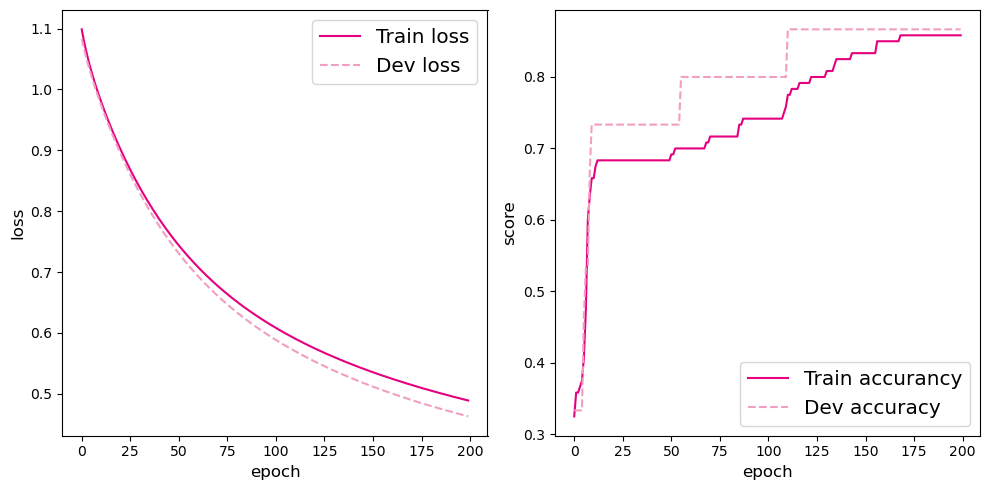

In [8]:
from nndl_study import plot

plot(runner, fig_name="linear-acc3.pdf")

### 3.3.4 模型评价

In [9]:
# 加载最优模型
runner.load_model("best_model.pdparams")
# 模型评价
score, loss = runner.evaluate([X_test, y_test])
print("[Test] score/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] score/loss: 0.6000/0.6674


### 3.3.5 模型预测


In [25]:
# 预测测试集数据
logits = runner.predict(X_test)
# 观察其中一条样本的预测结果
pred = paddle.argmax(logits[0]).numpy()  # argmax 返回最大值的索引值
pred = paddle.to_tensor([pred])  # .numpy默认返回numpy数组，
# 但零维数组只会返回int 或 float型, 所以需要to_tensor来强制转换
# 获取该样本概率最大的类别
label = y_test[0].numpy()
label = paddle.to_tensor([label])
# 输出真实类别与预测类别
print("The true category is {} and the predicted category is {}".format(label[0], pred[0]))

The true category is 1 and the predicted category is 1
